In [19]:
#UNIVARIATE ANALYSIS

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
cleaned_df = pd.read_csv("cleaned_itsm_data.csv")

print("Cleaned dataset loaded successfully!")
print("Shape:", cleaned_df.shape)

Cleaned dataset loaded successfully!
Shape: (360000, 29)


In [22]:
numerical_columns = cleaned_df.select_dtypes(include="number").columns

print("Numerical Columns:")
print(list(numerical_columns))

Numerical Columns:
['ticket_id', 'company_id', 'requester_user_id', 'assigned_agent_id', 'reopen_count', 'customer_satisfaction_rating', 'sla_log_id', 'sla_target_minutes', 'actual_minutes', 'breach_minutes', 'sla_variance_minutes', 'sla_performance_percentage']


In [23]:
##Basic Statistical Summary

print(cleaned_df[numerical_columns].describe().T)

                                 count           mean            std  \
ticket_id                     360000.0   90000.500000   51961.596395   
company_id                    360000.0     224.556350     131.112236   
requester_user_id             360000.0     810.207456     391.592306   
assigned_agent_id             360000.0     491.009867     282.983340   
reopen_count                  360000.0       0.000000       0.000000   
customer_satisfaction_rating  298554.0       3.008608       1.412116   
sla_log_id                    360000.0  180000.500000  103923.192791   
sla_target_minutes            360000.0     780.000000     660.000917   
actual_minutes                360000.0    3053.570175    2840.728434   
breach_minutes                360000.0    2281.555794    2172.623041   
sla_variance_minutes          360000.0    2273.570175    2181.119314   
sla_performance_percentage    360000.0     293.843201     135.729290   

                                     min           25%         

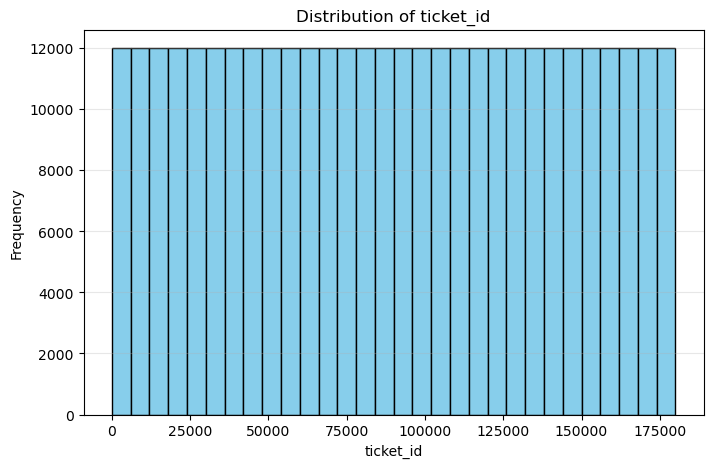

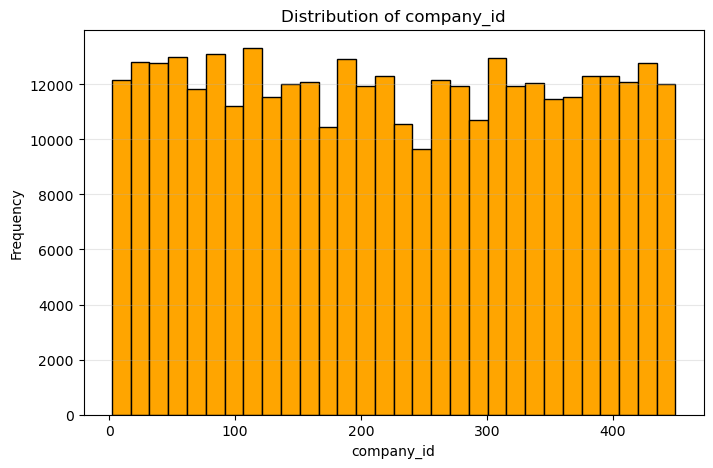

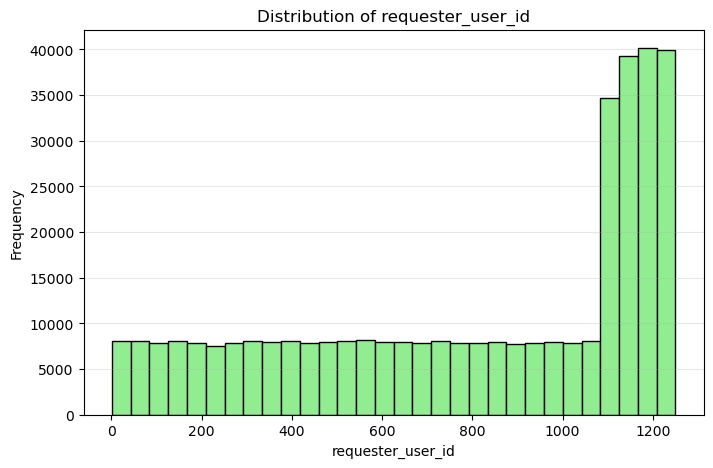

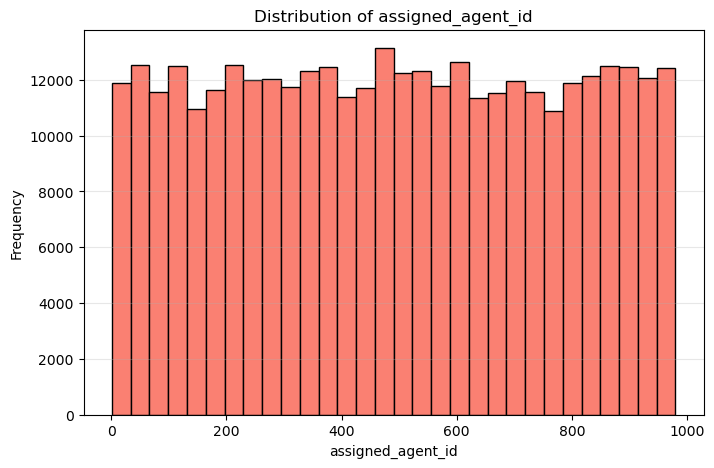

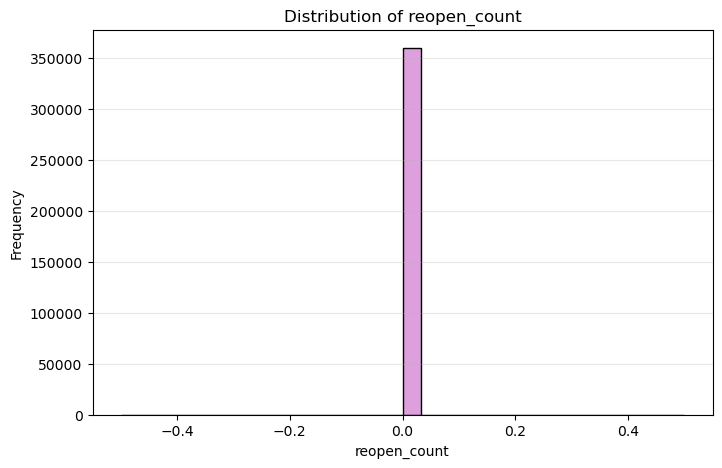

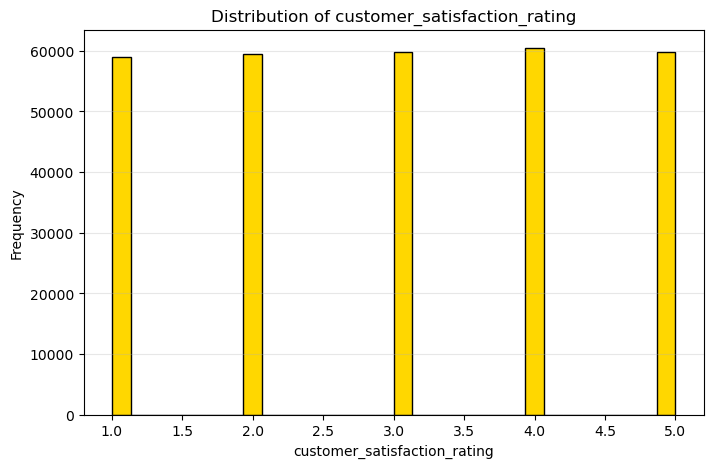

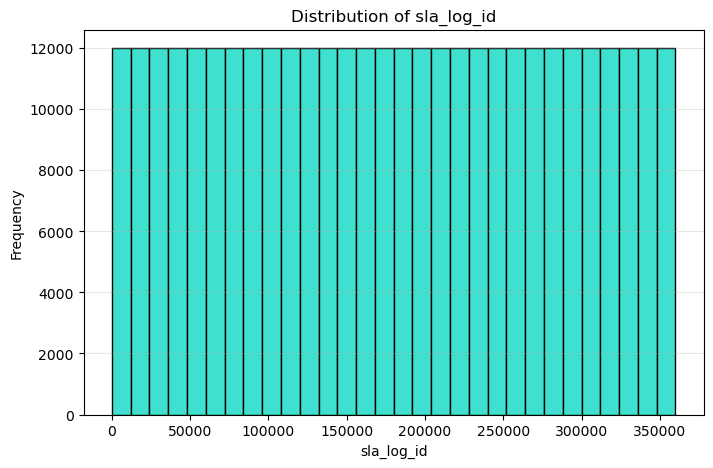

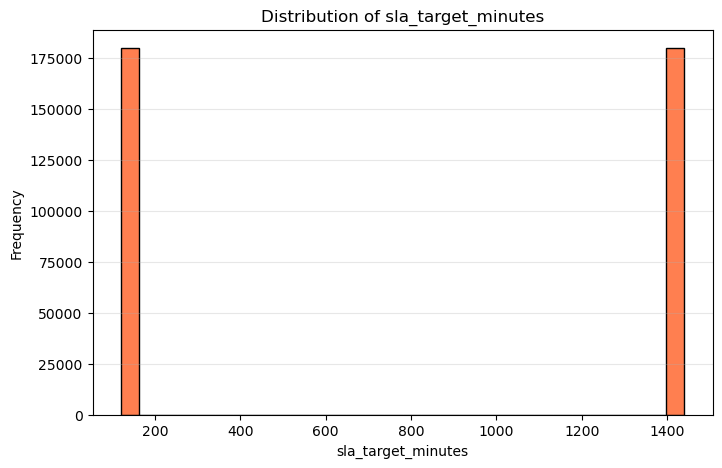

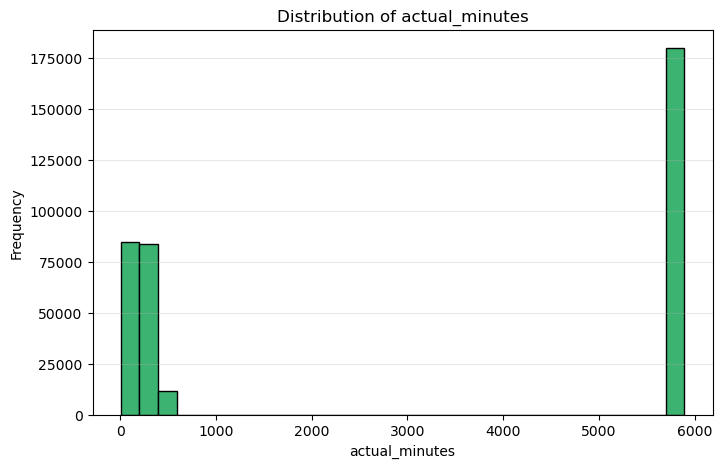

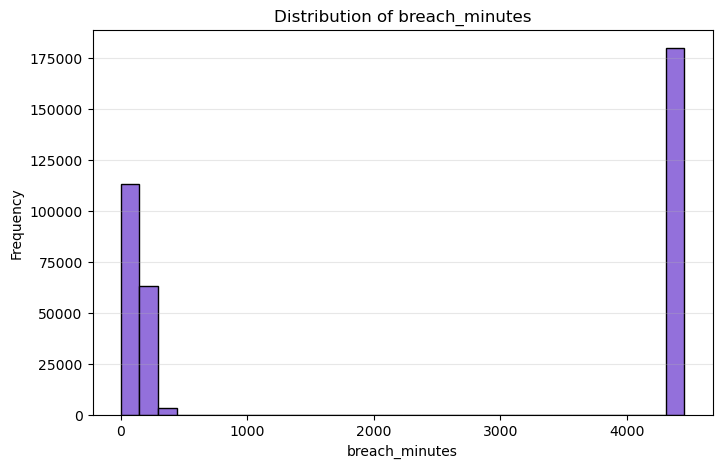

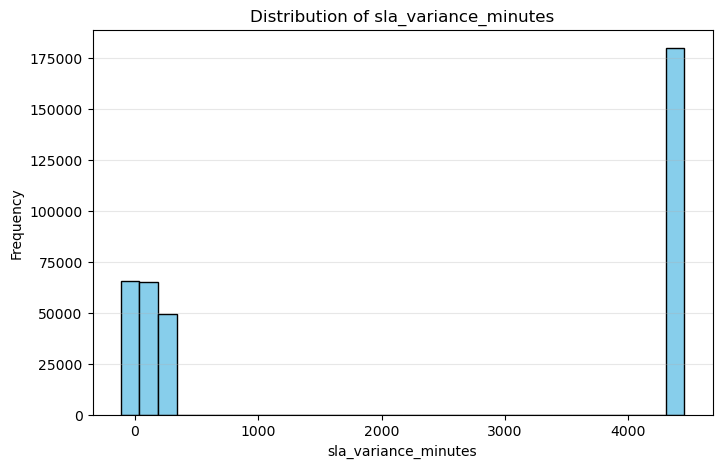

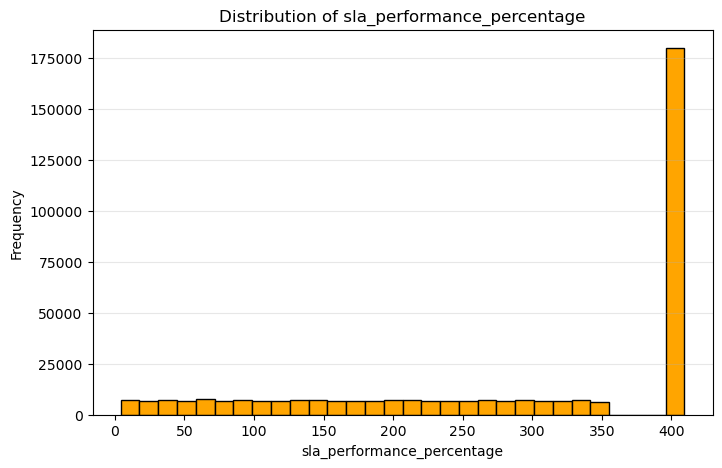

In [24]:
##Numerical Variable Distributions

colors = [
    "skyblue", "orange", "lightgreen", "salmon",
    "plum", "gold", "turquoise", "coral",
    "mediumseagreen", "mediumpurple"
]

for i, col in enumerate(numerical_columns):
    plt.figure(figsize=(8, 5))
    plt.hist(
        cleaned_df[col].dropna(),
        bins=30,
        color=colors[i % len(colors)],
        edgecolor="black"
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

In [25]:
##Check Categorical Columns

categorical_columns = cleaned_df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(list(categorical_columns))

Categorical Columns:
['ticket_number', 'opened_at', 'resolved_at', 'closed_at', 'ticket_type', 'category', 'sub_category', 'priority', 'impact', 'urgency', 'ticket_status', 'source_channel', 'resolution_code', 'created_month', 'sla_type', 'sla_status', 'measured_at']


CSAT Distribution:
customer_satisfaction_rating
1.0    59022
2.0    59496
3.0    59758
4.0    60446
5.0    59832
Name: count, dtype: int64


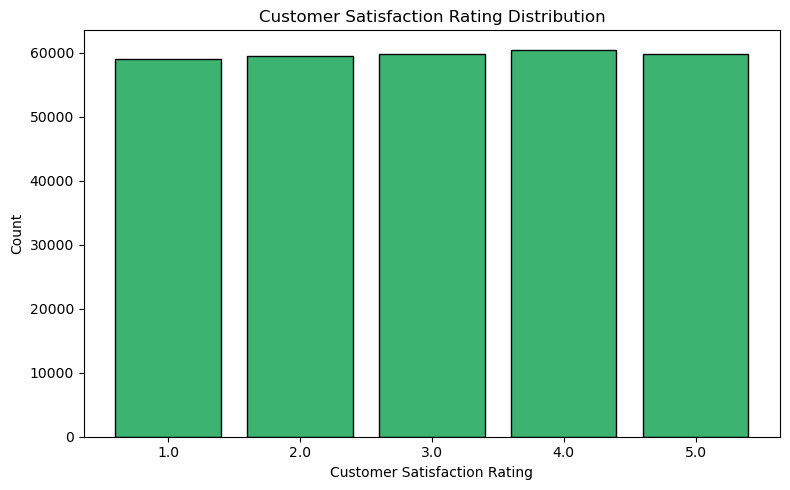

In [26]:
#Customer Satisfaction Rating Distribution

csat_counts = cleaned_df["customer_satisfaction_rating"].value_counts().sort_index()

print("CSAT Distribution:")
print(csat_counts)

plt.figure(figsize=(8, 5))
plt.bar(
    csat_counts.index.astype(str),
    csat_counts.values,
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Customer Satisfaction Rating Distribution")
plt.xlabel("Customer Satisfaction Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [29]:
new_numerical_columns = [
    "sla_variance_minutes",
    "sla_performance_percentage"
]

print("New Numerical Columns:")
print(new_numerical_columns)

New Numerical Columns:
['sla_variance_minutes', 'sla_performance_percentage']


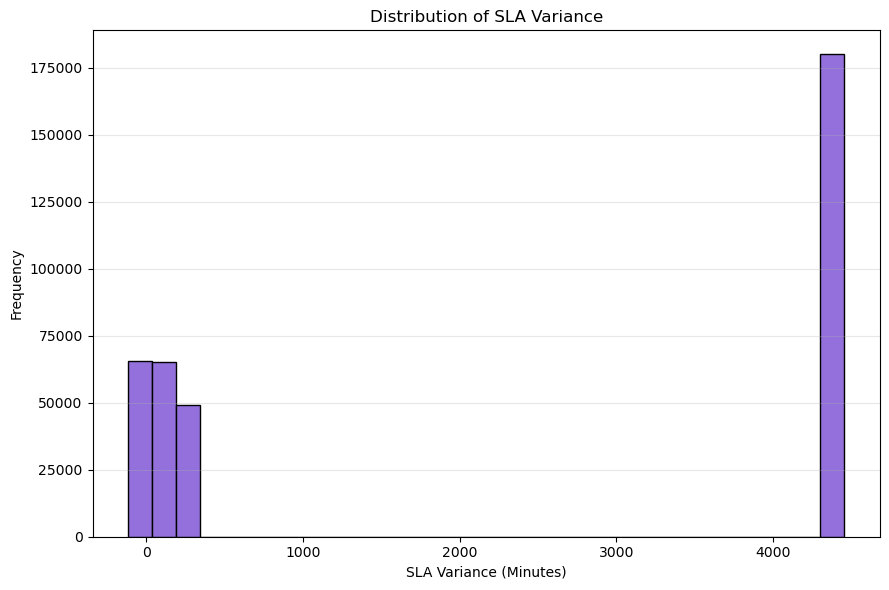

In [30]:
plt.figure(figsize=(9, 6))

plt.hist(
    cleaned_df["sla_variance_minutes"].dropna(),
    bins=30,
    color="mediumpurple",
    edgecolor="black"
)

plt.title("Distribution of SLA Variance")
plt.xlabel("SLA Variance (Minutes)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "SLA_Variance_Distribution.svg",
    format="svg"
)

plt.show()

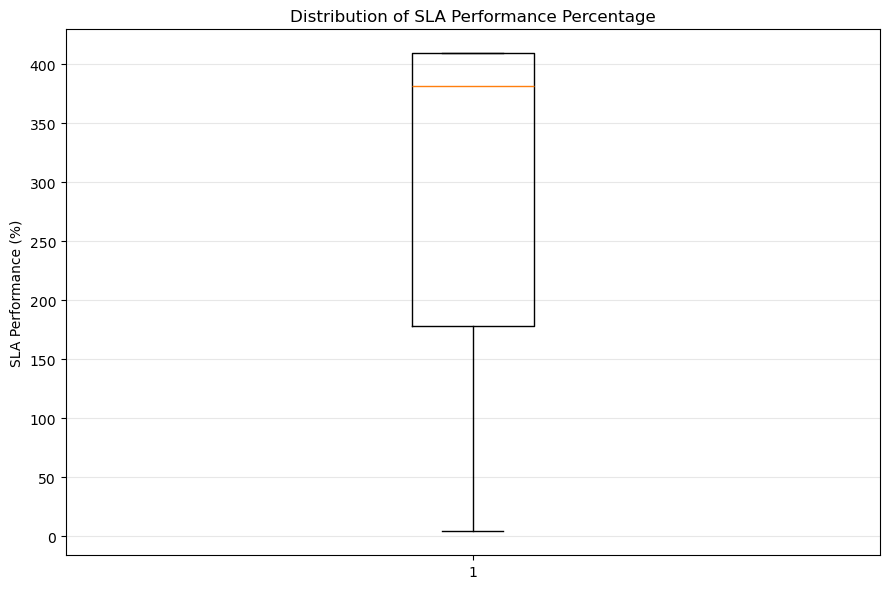

In [31]:
plt.figure(figsize=(9, 6))

plt.boxplot(
    cleaned_df["sla_performance_percentage"].dropna()
)

plt.title("Distribution of SLA Performance Percentage")
plt.ylabel("SLA Performance (%)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "SLA_Performance_Percentage_Distribution.svg",
    format="svg"
)

plt.show()

In [32]:
##CSAT Summary Statistics

print("Mean CSAT:", cleaned_df["customer_satisfaction_rating"].mean())
print("Median CSAT:", cleaned_df["customer_satisfaction_rating"].median())
print("Missing CSAT:", cleaned_df["customer_satisfaction_rating"].isnull().sum())
print("Univariate Analysis Completed!!!!")

Mean CSAT: 3.00860815798817
Median CSAT: 3.0
Missing CSAT: 61446
Univariate Analysis Completed!!!!
